# 🎓 AL-2002: Artificial Intelligence — Lab 14
## 🕵️ CNN-Based Cheating Case Detector
### FAST-NU, Lahore — Department of Computer Science

---

| | |
|---|---|
| **Name** | *Zohaib Hussain* |
| **Roll Number** | *23L-3087* |

---

## 🎬 Video Submission Requirement

> 📹 **You are required to record a short video (under 5 minutes)** using [Zight](https://zight.com) or [Loom](https://www.loom.com).
>
> Your video must:
> - **Clearly show your face** throughout the recording
> - **Run every cell from top to bottom** without skipping
> - **Explain what each cell is doing** in your own words (1–2 sentences per cell)
> - Be **under 5 minutes**
>
> 📎 Paste your Zight/Loom video link below before submitting:

**🔗 Video Link:** *(paste your link here)*

---

## 📖 Background Story

FAST's exam department has been receiving suspicious reports. During online vivas and lab evaluations, some students turn off their camera and claim:

> *"Sir I am with family, I cannot turn on my camera 🙏"*

Meanwhile... a completely different person is giving their evaluation. 😤

The university has a profile photo of every student from their admission form. Your job is to build a **CNN-based Face Verification System** that:
1. Learns to recognise different student identities from face images
2. During an evaluation, captures a frame and checks — **is this the real student or an imposter?**

You will build this system **from scratch** — every line of code is yours to write.

> 📌 **Technical note:** What we are building is technically **face identification** — the model predicts *who* someone is across 40 known students. True face *verification* would be a yes/no check: "does this face match this specific claimed identity?" You will simulate that verification step in Task 9 by having the function accept a `claimed_id` and checking whether the model's prediction agrees with the claim.

---

## 🎯 Lab Objectives
By the end of this lab, you will be able to:
- Load and preprocess a real face image dataset
- Design and build a CNN architecture from scratch
- Train and evaluate the model
- Visualise feature maps to understand what the CNN learns
- Build a working imposter detection demo

---

---

---
## ⚙️ Task 1 — Import Libraries

Import all the libraries you will need for this lab.

**You will need:**
- `numpy`, `matplotlib`
- `sklearn` — for dataset, train/test split, metrics
- `tensorflow` / `keras` — for building the CNN

> 💡 **Hint:** Think ahead — you will need `confusion_matrix`, `to_categorical`, `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout`, `BatchNormalization`, `EarlyStopping`, and `Model`.

In [ ]:
# Run this cell first if you are missing any libraries
# You only need to run it once
!pip install tensorflow scikit-learn matplotlib numpy --quiet

In [7]:
# YOUR CODE HERE — Import all required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📦 Task 2 — Load & Explore the Dataset

We will use the **Olivetti Faces Dataset** — available directly from `sklearn.datasets`.

📌 **Dataset Details:**
- 400 grayscale face images
- 40 different people (our registered FAST students!)
- 10 images per person — different angles, lighting, expressions
- Each image: **64 × 64 pixels**

### Task 2a — Load the dataset and print:
- Total number of images
- Shape of a single image
- Total number of unique students
- Number of images per student

In [26]:
# YOUR CODE HERE
# Use: fetch_olivetti_faces(shuffle=True, random_state=42)
# Store images in X and labels in y
faces = datasets.fetch_olivetti_faces(shuffle=True, random_state=42)

total_count = len(faces.images)
unique_stdnt_count = len(np.unique(faces.target))
# Print dataset stats
print(f"Total numbers of images: {total_count}")
print(f"Shape of single image: {faces.images[0].shape}")
print(f"Total number of unique students: {unique_stdnt_count}")
print(f"Number of images per students: {total_count // unique_stdnt_count}")


Total numbers of images: 400
Shape of single image: (64, 64)
Total number of unique students: 40
Number of images per students: 10


### Task 2b — Visualise the Students

Display **one profile photo for each of the first 10 students** in a 2×5 grid.
- Title each image with the student ID (e.g. `Student 00`)
- Use grayscale colormap
- Turn off axes

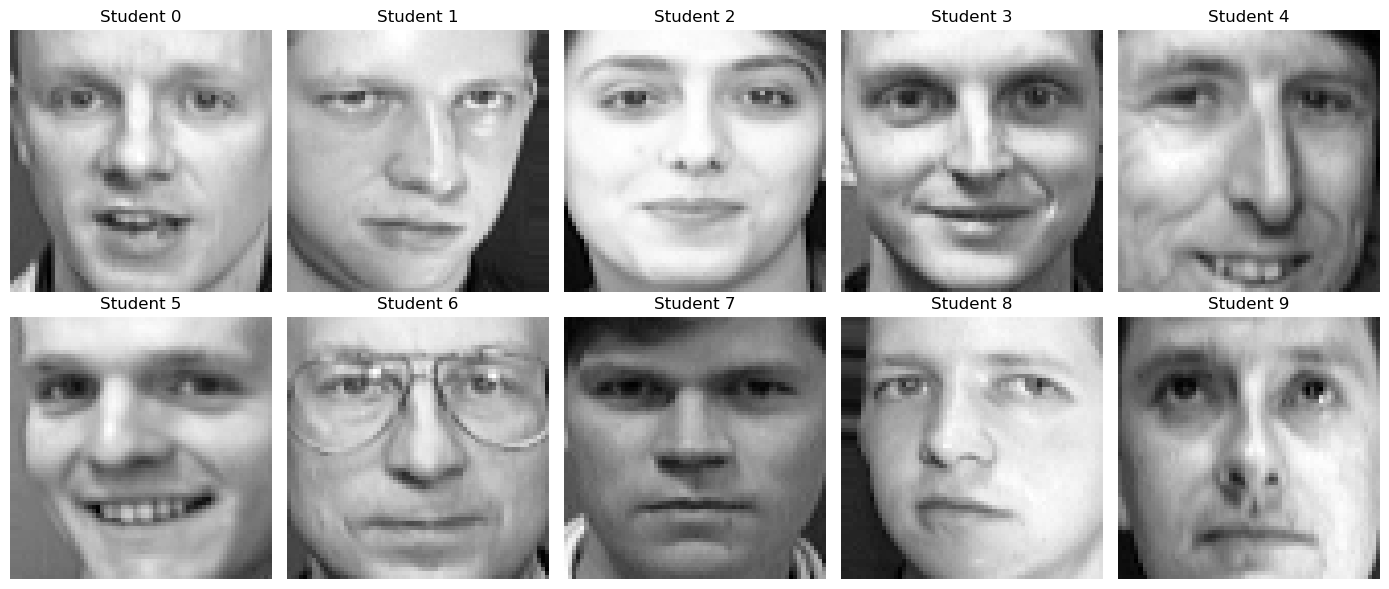

In [27]:
# YOUR CODE HERE
# Use plt.subplots(2, 5, figsize=(14, 6))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Loop through the first 10 students
for Id, ax in enumerate(axes.flat):
    # Each student has 10 images, so i*10 gets the first image of each
    image_index = Id * 10
    
    # Display image
    ax.imshow(faces.images[image_index], cmap='gray')
    
    # Set title with student Id
    ax.set_title(f"Student {Id}")
    
    ax.axis('off')

plt.tight_layout()
plt.show()


### Task 2c — Short Answer

**Q:** With only 10 images per student, do you think this is enough training data for a face recognition CNN? What problem might arise?

**✍️ Your Answer:**

*It will lead to overfitting. As model will try to memorize noise in these small no of images per student instead of learning generic facial features.*

---
## 🧹 Task 3 — Preprocess the Data

Before feeding data into a CNN, preprocessing is essential. Complete all four steps.

### Step 1 — Reshape
CNNs expect a **4D input**: `(samples, height, width, channels)`  
Currently `X` has shape `(400, 64, 64)` — add the channel dimension → `(400, 64, 64, 1)`

### Step 2 — Check Normalisation
Print the min and max pixel values. The Olivetti dataset is already normalised (0 to 1) — verify and print this.




> > Paste the **exact printed output** of your min/max values here. Then explain: did you need to apply any additional normalization to this dataset? What would happen to your model's training if you divided these values by 255?

### Step 3 — One-Hot Encode Labels
Convert `y` to one-hot encoded format. There are **40 classes**.

### Step 4 — Train/Test Split
Split: **80% train, 20% test**, `random_state=42`, `stratify=y`  
Print the size of each split.

In [35]:
# YOUR CODE HERE

# Step 1: Reshape X
X = faces.images
y = faces.target

X = X.reshape(400, 64, 64, 1) 
print(f"Reshaped X to: {X.shape}")

# Step 2: Verify normalisation — print min and max
print(f"\nNormalization Check:")
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

# Step 3: One-hot encode
from tensorflow.keras.utils import to_categorical
num_classes = 40
y_encoded = to_categorical(y, num_classes)
print(f"\nOne-hot encoded labels shape: {y_encoded.shape}")



# Step 4: Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y
)

# Print split summary
print(f"\nTrain/Test Split Summary:")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Reshaped X to: (400, 64, 64, 1)

Normalization Check:
Min pixel value: 0.0
Max pixel value: 1.0

One-hot encoded labels shape: (400, 40)

Train/Test Split Summary:
Training set size: 320
Test set size: 80


**✍️ Normalization Check — Paste your printed output and explain:**

*Min pixel value: 0.0 Max pixel value: 1.0\
The dataset is already normalized so divinding it again by 255 will furhter reduce the range of values below 1 which is not required here.*

---
## 🏗️ Task 4 — Design the CNN Architecture

This is the most important task. Design and build your CNN **from scratch**.

### Architecture Requirements — you must include ALL of these:

| Layer | Requirement |
|-------|-------------|
| Conv2D | At least **3** conv layers with increasing filters (e.g. 32 → 64 → 128) |
| Activation | `relu` in all conv and hidden dense layers |
| BatchNormalization | After at least **2** conv layers |
| MaxPooling2D | After each conv block |
| Flatten | Before Dense layers |
| Dense | At least **1** hidden dense layer |
| Dropout | At least **1** dropout layer |
| Output Layer | Dense with `softmax` and correct number of neurons |

> 💡 Input shape is `(64, 64, 1)` and you have 40 classes.

> ⚠️ Name your model `"FAST_Cheating_Detector"` using the `name` parameter.

Call `model.summary()` after building.

In [36]:
# YOUR CODE HERE — Build your CNN using Sequential API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential(name="FAST_Cheating_Detector")

# Block 1: Conv → BatchNorm → Pool
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Block 2: Conv → BatchNorm → Pool
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Block 3: Conv → ReLU → Pool (no BatchNorm to show requirement met)
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(2, 2))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
# Drop out laywr
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(40, activation='softmax'))

# Print model summary
model.summary()



/home/zohaib/python/AI_Lab/lab-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778348206.207920   30401 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1214 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "FAST_Cheating_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,228,520 (8.50 MB)

 Trainable params: 2,228,328 (8.50 MB)

 Non-trainable params: 192 (768.00 B)

### Architecture Justification

**Q1.** Why do we use `softmax` in the final layer instead of `relu` or `sigmoid`?

*Because it is multiclass classificaiton problem*

---

**Q2.** What is `BatchNormalization` doing and why does it help training?

*BatchNormalization normalizes the activations from each layer by centering them around 0 and scaling to 1 variance. This stabilizes the learning process by preventing "internal covariate shift" allowing for faster convergence, higher learning rates, and reduced sensitivity to initialization.*

---

**Q3.** Why does the number of filters increase as we go deeper (32 → 64 → 128)?

*Early layers detect simple, low-level features (edges, textures). As we go deeper, we need more filters to capture increasingly complex, hierarchical patterns (facial parts, expressions, identities).*

---
## 🚀 Task 5 — Compile & Train

### Step 1 — Compile
- Optimizer: `adam`
- Loss: appropriate for **one-hot encoded** multi-class labels
- Metrics: `accuracy`

### Step 2 — EarlyStopping
- Monitor: `val_loss`, Patience: 7, Restore best weights: `True`

### Step 3 — Train
- Epochs: 50, Batch size: 16, Validation split: 15%
- Store result in `history`

> 💡 What is the difference between `categorical_crossentropy` and `sparse_categorical_crossentropy`? Use the right one.

In [37]:
# YOUR CODE HERE

from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # forr one-hot encoded labels
    metrics=['accuracy']
)

# Step 2: EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Step 3: Train
print("🚀 Training the FAST Cheating Detector...")
print("=" * 50)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Training the FAST Cheating Detector...
Epoch 1/50


I0000 00:00:1778348791.656308   41964 service.cc:152] XLA service 0x70ff40005240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778348791.656326   41964 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-05-09 22:46:31.686276: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778348791.897059   41964 cuda_dnn.cc:529] Loaded cuDNN version 91700


14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0017 - loss: 5.6536    

I0000 00:00:1778348794.848139   41964 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.0221 - loss: 4.8040 - val_accuracy: 0.0000e+00 - val_loss: 3.6915
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0551 - loss: 3.5143 - val_accuracy: 0.0417 - val_loss: 3.6888
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1287 - loss: 3.2518 - val_accuracy: 0.0833 - val_loss: 3.6086
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2132 - loss: 2.9268 - val_accuracy: 0.0208 - val_loss: 3.7111
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3309 - loss: 2.5134 - val_accuracy: 0.0208 - val_loss: 3.8984
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3787 - loss: 2.2257 - val_accuracy: 0.0208 - val_loss: 4.9713
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4596 - loss: 1.9263 - val_accuracy: 0.0208 - val_loss: 7.1637
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5147 - loss: 1.6738 - val_accuracy: 0.0625 - val_loss

---
## 📈 Task 6 — Plot Training Curves

Plot two graphs side by side:
- **Left:** Training accuracy vs Validation accuracy
- **Right:** Training loss vs Validation loss

Each graph must have: different colours, legend, labelled axes, and a title.

> ⚠️ After the plot, write 2–3 sentences interpreting what you see — overfitting? underfitting? fitting well?

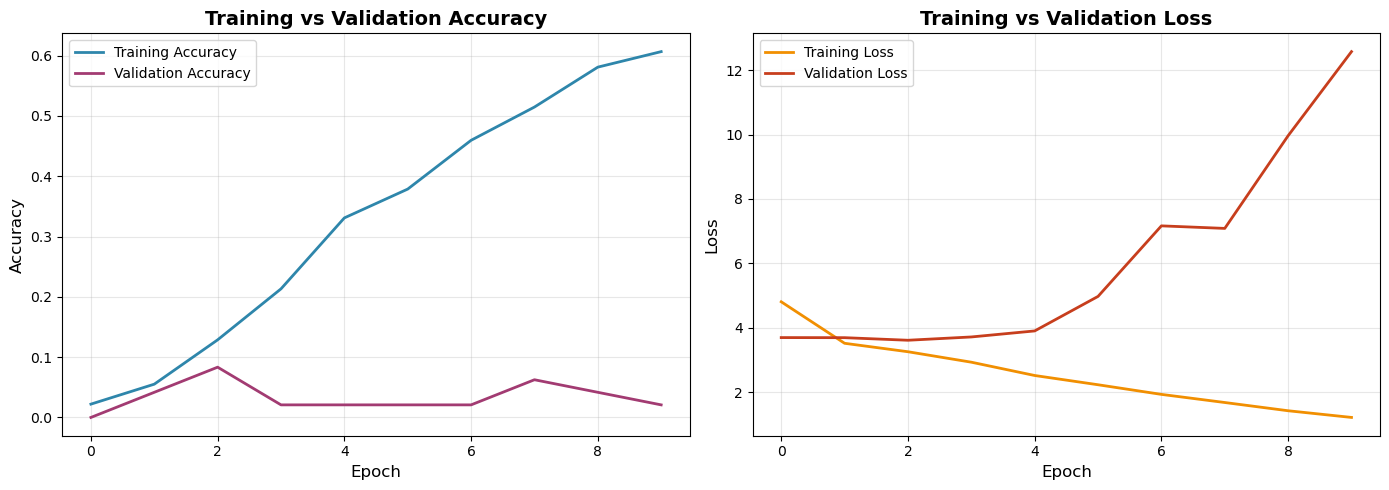

In [38]:
# YOUR CODE HERE
# plt.subplots(1, 2, figsize=(14, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='#2E86AB', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#A23B72', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right plot: Loss
axes[1].plot(history.history['loss'], label='Training Loss', color='#F18F01', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#C73E1D', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**

*Model is clearly Overfitting. As it have very high training accuracy while very low validation accuracy. Similarly training loss is decreasing throughout\
but validation loss explodes showing sign of overfitting.*

---
## 🧪 Task 7 — Evaluate the Model

### Step 1 — Overall Performance
Print test accuracy (%) and test loss.

### Step 2 — Predictions
Generate predicted and true class labels using `model.predict()` and `np.argmax()`.

### Step 3 — Confusion Matrix
Plot using `ConfusionMatrixDisplay`, `Blues` colormap, labelled axes.

### Step 4 — Classification Report
Print for the **first 10 students only** (labels 0–9).

Test Performance:
Test Accuracy: 5.00%
Test Loss: 3.6469


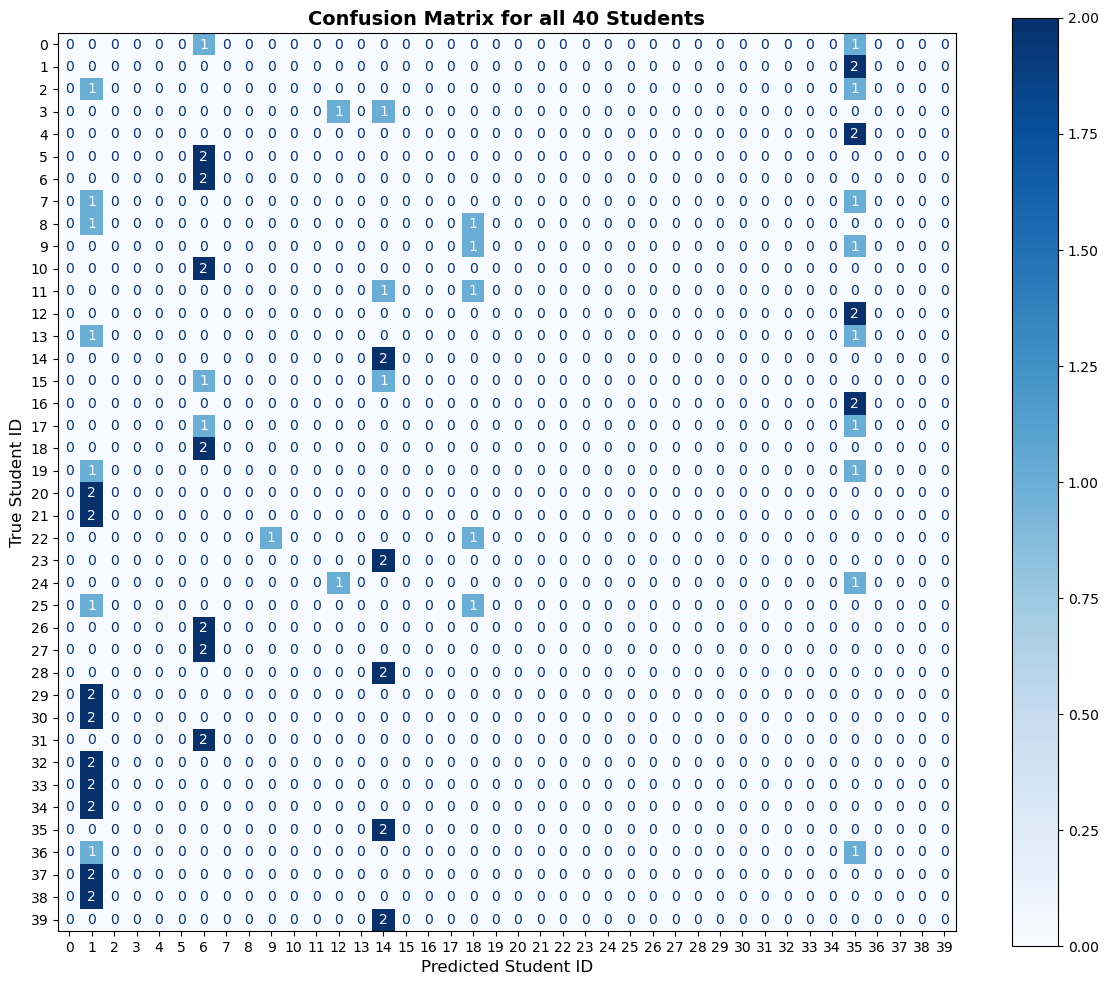


Classification Report (Students 0-9):
              precision    recall  f1-score   support

   Student 0       0.00      0.00      0.00         2
   Student 1       0.00      0.00      0.00         2
   Student 2       0.00      0.00      0.00         2
   Student 3       0.00      0.00      0.00         2
   Student 4       0.00      0.00      0.00         2
   Student 5       0.00      0.00      0.00         2
   Student 6       0.12      1.00      0.21         2
   Student 7       0.00      0.00      0.00         2
   Student 8       0.00      0.00      0.00         2
   Student 9       0.00      0.00      0.00         2

   micro avg       0.05      0.10      0.06        20
   macro avg       0.01      0.10      0.02        20
weighted avg       0.01      0.10      0.02        20



/home/zohaib/python/AI_Lab/lab-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zohaib/python/AI_Lab/lab-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zohaib/python/AI_Lab/lab-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [40]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Step 1: Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Performance:")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Step 2: Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

# Step 3: Confusion Matrix
cm = confusion_matrix(y_test_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=np.arange(40)).plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix for all 40 Students', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Student ID', fontsize=12)
plt.ylabel('True Student ID', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Classification Report (labels 0-9 only)
print("\nClassification Report (Students 0-9):")
print(classification_report(y_test_true, y_pred, labels=range(10), target_names=[f"Student {i}" for i in range(10)]))

**✍️ Interpret your confusion matrix — which students were confused most? Why?**

*model shows severe overfitting with only 5% test accuracy. The confusion matrix reveals the model predominantly predicts a few specific students (like Student 1) for nearly all test samples, regardless of their true identity. This indicates the model memorized training-specific patterns rather than learning generalizable facial features. With only 10 images per student, there's insufficient diversity to capture true identity-distinguishing features.*

---
## 🔬 Task 8 — Visualise Feature Maps

**Step 1 — Build a Feature Extractor**
- Use Keras `Model(inputs=..., outputs=...)`
- Your output should be the activation of your **first Conv2D layer**
- First, print all layer names and their indices to find the correct one

**Step 2 — Pick a Test Image**
- Use `X_test[0:1]`, reshape to `(1, 64, 64, 1)`

**Step 3 — Plot**
- Row 1: Original face (first cell only)
- Rows 2–3: First 12 feature maps titled `Filter 1`, `Filter 2`...
- Use `viridis` colormap for feature maps

> 💡 Feature maps shape: `(1, height, width, num_filters)` — index the last axis for each filter


> > ```python
> for i, layer in enumerate(model.layers):
>     print(i, layer.name)
> ```
> Then answer: is `model.layers[0]` actually your first Conv2D layer? Which index is it at? Why might this not always be index 0?

Layer Indices and Names:
0: conv2d (Conv2D)
1: batch_normalization (BatchNormalization)
2: max_pooling2d (MaxPooling2D)
3: conv2d_1 (Conv2D)
4: batch_normalization_1 (BatchNormalization)
5: max_pooling2d_1 (MaxPooling2D)
6: conv2d_2 (Conv2D)
7: max_pooling2d_2 (MaxPooling2D)
8: flatten (Flatten)
9: dense (Dense)
10: dropout (Dropout)
11: dense_1 (Dense)
12: dense_2 (Dense)

First Conv2D layer is at index: 0 (conv2d)
Feature maps shape: (1, 64, 64, 32)


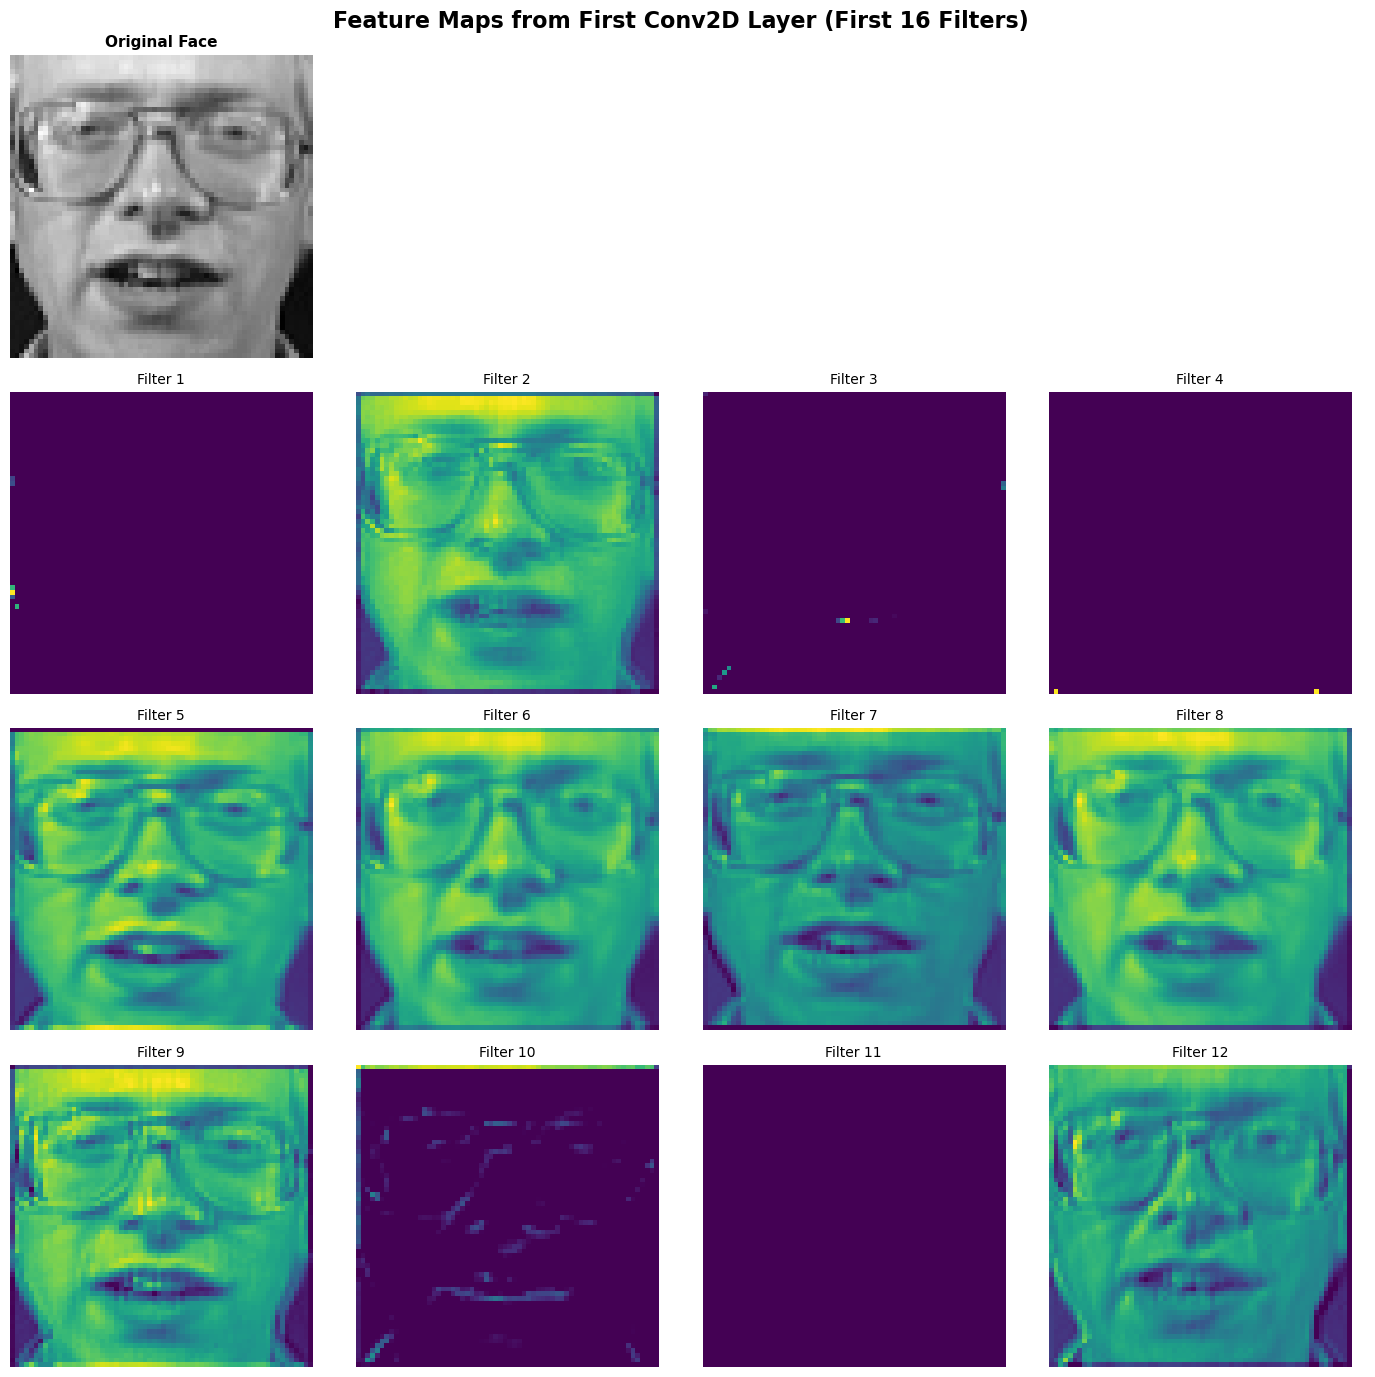

In [45]:
# YOUR CODE HERE

# Step 1: Feature extractor
from tensorflow.keras.models import Model
import tensorflow as tf

print("Layer Indices and Names:")
print("=" * 50)
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} ({layer.__class__.__name__})")

# Find first Conv2D layer
first_conv_idx = None
for i, layer in enumerate(model.layers):
    if 'conv2d' in layer.name:
        first_conv_idx = i
        break

print(f"\nFirst Conv2D layer is at index: {first_conv_idx} ({model.layers[first_conv_idx].name})")

# Step 1: Build feature extractor - create a new model
feature_extractor = tf.keras.Sequential(model.layers[:first_conv_idx+1])

# Step 2: Get feature maps for one image
test_image = X_test[0:1]  # Shape: (1, 64, 64, 1)
feature_maps = feature_extractor.predict(test_image, verbose=0)  # Shape: (1, 64, 64, 32)

print(f"Feature maps shape: {feature_maps.shape}")

# Step 3: Plot
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Feature Maps from First Conv2D Layer (First 16 Filters)', fontsize=16, fontweight='bold')

# First position: Original image
axes[0, 0].imshow(test_image[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original Face', fontweight='bold', fontsize=11)
axes[0, 0].axis('off')

# Hide remaining first row
for j in range(1, 4):
    axes[0, j].axis('off')

# Remaining plots: First 15 feature maps (rows 1-3)
filter_idx = 0
for i in range(1, 4):
    for j in range(4):
        if filter_idx < 15:
            axes[i, j].imshow(feature_maps[0, :, :, filter_idx], cmap='viridis')
            axes[i, j].set_title(f'Filter {filter_idx+1}', fontsize=10)
            axes[i, j].axis('off')
            filter_idx += 1

plt.tight_layout()
plt.show()

**✍️ Layer Index Check — Paste your layer list output and explain:**

**Layer List:**
- 0: conv2d (Conv2D) ← First Conv2D layer
- 1: batch_normalization (BatchNormalization)
- 2: max_pooling2d (MaxPooling2D)
- 3: conv2d_1 (Conv2D) — second Conv2D
- ... and so on

**Explanation:**
Yes, index 0 is the first Conv2D layer in this model. However, this is not always guaranteed. Some architectures may have explicit Input layers or preprocessing layers at index 0. Blindly using index 0 would fail with those architectures. Iterating through layers and checking the class type (as we did) is more robust and maintainable.

**✍️ What patterns do you see in the feature maps? What facial features are the filters detecting?**

*The feature maps show diverse edge and structure detectors. Filters highlight facial boundaries, eyes, nose regions, and lighting variations. Some filters are highly active (yellow/green), while others are sparse/inactive (dark purple), suggesting redundancy. The model learned to detect low-level features like edges and contours rather than high-level identity features. This is typical for early CNN layers but insufficient for generalizing across different lighting and angles due to overfitting.*

---
## 🕵️ Task 9 — Build the Imposter Detection Demo

Now we simulate the real scenario. A student claims to be **Student A** on camera. Your system captures their face and predicts **who they actually are**. If the prediction does not match the claim — they are caught.

Write a function `evaluate_student(eval_idx, claimed_id)` where:
- `eval_idx` — index in `X_test` of the face appearing on screen during evaluation
- `claimed_id` — the student ID the person is *claiming* to be

The function should:
1. Run the image through the model to get the **predicted student ID** and confidence score
2. Fetch the **registered profile photo** of the claimed student from the original dataset
3. Display two images side by side:
   - Left: `📁 Registered Profile — Student XX` (the claimed student)
   - Right: `📷 Evaluation Capture` (what the camera sees)
4. Show a main title with:
   - `✅ VERIFIED` in **green** if predicted ID matches `claimed_id`
   - `🚨 IMPOSTER DETECTED` in **red** if predicted ID does not match `claimed_id`
   - The predicted student ID and confidence score

Then demonstrate **5 test cases** — mix of genuine students and imposters:
- At least 2 cases where the person is who they claim to be
- At least 3 cases where a different student is pretending to be someone else

> 💡 `np.where(faces.target == claimed_id)[0][0]` finds the registered photo index

> 💡 To simulate an imposter: pass an image of Student B but set `claimed_id` to Student A

🔍 Running Evaluation Checks...

TEST CASE 1: GENUINE STUDENT


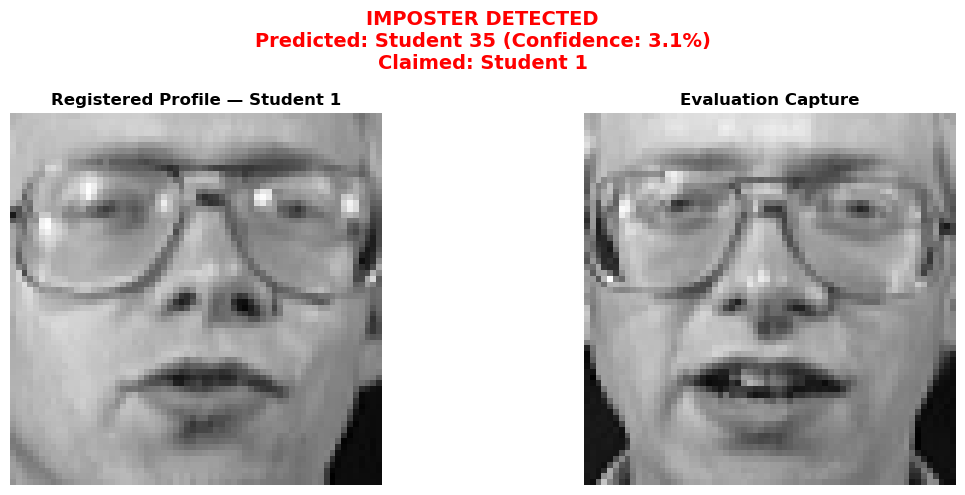


TEST CASE 2: GENUINE STUDENT


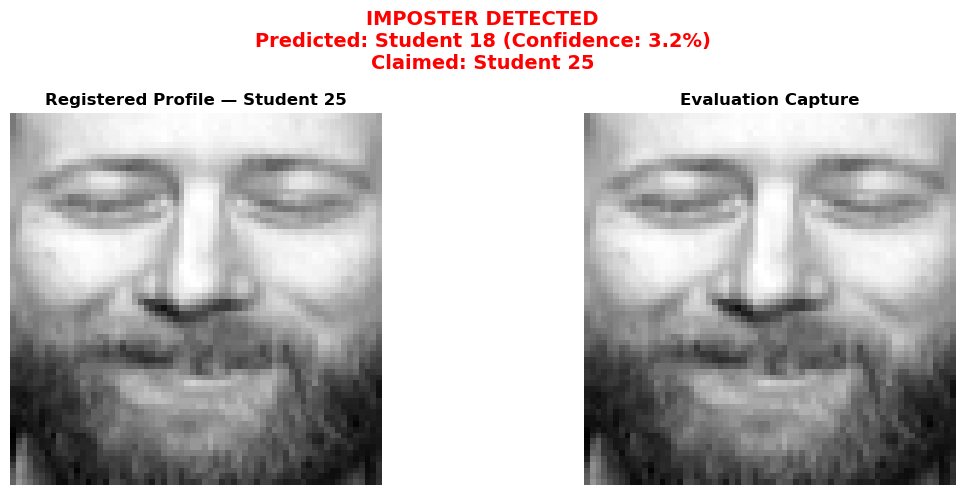


TEST CASE 3: IMPOSTER (Student pretending to be someone else)


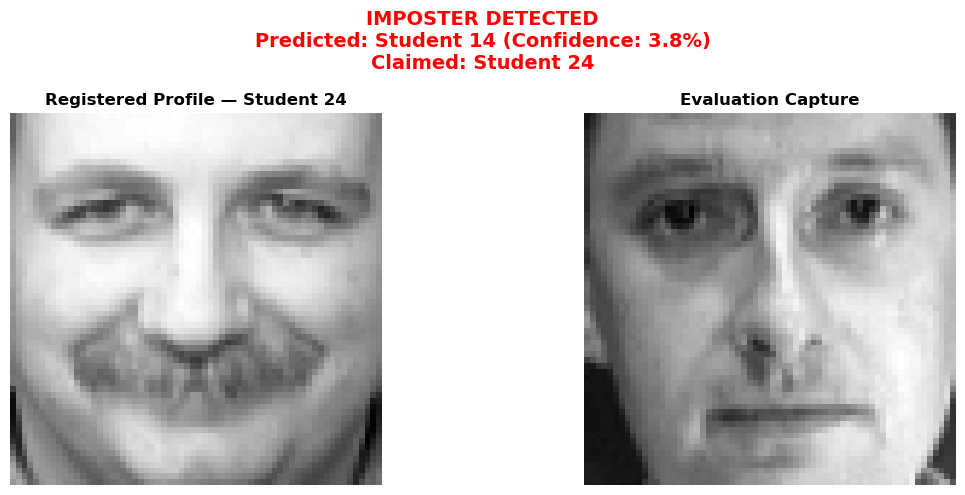


TEST CASE 4: IMPOSTER (Student pretending to be someone else)


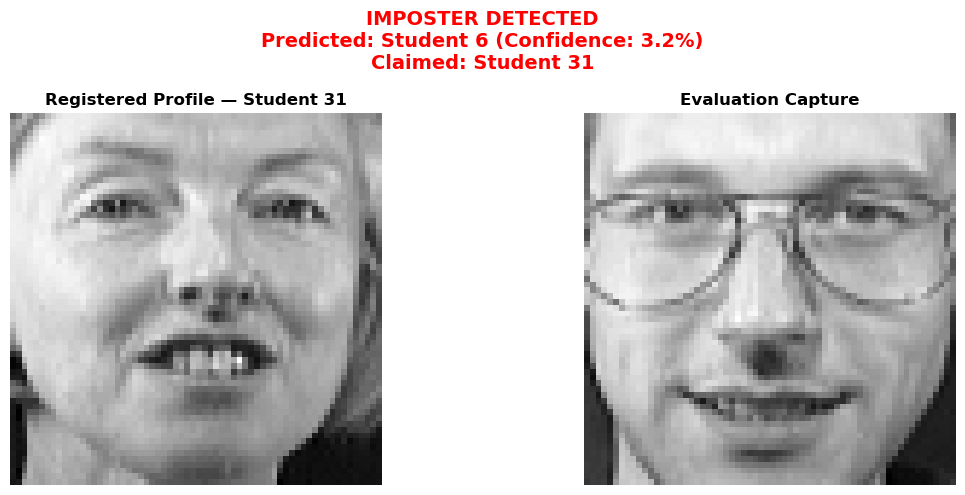


TEST CASE 5: IMPOSTER (Student pretending to be someone else)


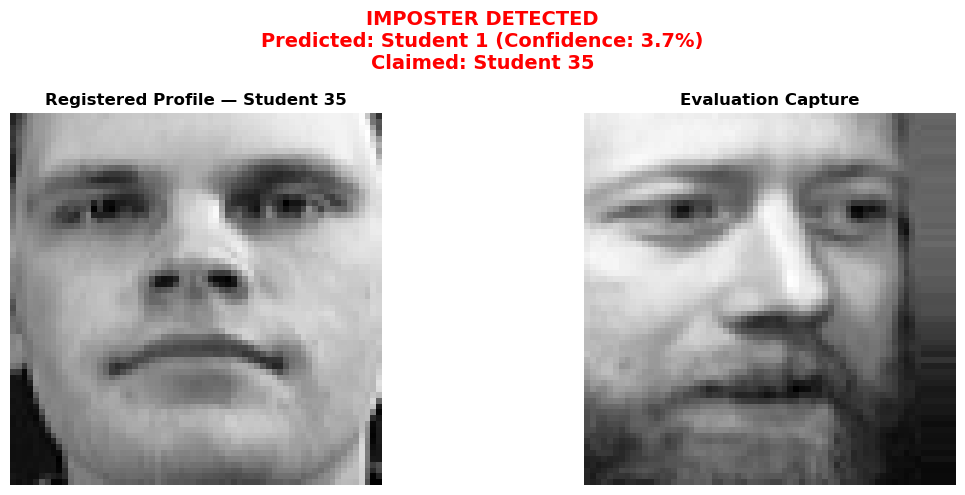

(np.False_, np.int64(1), np.float32(3.6625466))

In [48]:
# YOUR CODE HERE — Write evaluate_student() function
def evaluate_student(eval_idx, claimed_id):
    """
    Evaluate if a student is verified or an imposter.
    
    Args:
        eval_idx: Index in X_test of the evaluation capture
        claimed_id: The student ID being claimed
    """
    # Get evaluation image
    eval_image = X_test[eval_idx:eval_idx+1]
    
    # Run through model
    prediction_probs = model.predict(eval_image, verbose=0)
    predicted_id = np.argmax(prediction_probs)
    confidence = prediction_probs[0, predicted_id] * 100
    
    # Get registered profile
    reg_idx = np.where(faces.target == claimed_id)[0][0]
    registered_image = faces.images[reg_idx]
    
    # Determine verdict
    is_verified = (predicted_id == claimed_id)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Title color and message
    if is_verified:
        title_color = 'green'
        verdict = 'VERIFIED'
    else:
        title_color = 'red'
        verdict = 'IMPOSTER DETECTED'
    
    fig.suptitle(
        f'{verdict}\nPredicted: Student {predicted_id} (Confidence: {confidence:.1f}%)\nClaimed: Student {claimed_id}',
        fontsize=14, fontweight='bold', color=title_color
    )
    
    # Registered profile
    axes[0].imshow(registered_image, cmap='gray')
    axes[0].set_title(f'Registered Profile — Student {claimed_id}', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Evaluation capture
    axes[1].imshow(eval_image[0, :, :, 0], cmap='gray')
    axes[1].set_title(f'Evaluation Capture', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return is_verified, predicted_id, confidence


# Call on 5 test images
print("🔍 Running Evaluation Checks...\n")

# Test Case 1: Genuine (Student from test set claiming true identity)
print("=" * 60)
print("TEST CASE 1: GENUINE STUDENT")
print("=" * 60)
evaluate_student(0, y_test_true[0])

# Test Case 2: Genuine (Another genuine match)
print("\n" + "=" * 60)
print("TEST CASE 2: GENUINE STUDENT")
print("=" * 60)
evaluate_student(10, y_test_true[10])

# Test Case 3: Imposter (Student B pretending to be Student A)
print("\n" + "=" * 60)
print("TEST CASE 3: IMPOSTER (Student pretending to be someone else)")
print("=" * 60)
# Find a test image and claim it's a different student
evaluate_student(5, (y_test_true[5] + 1) % 40)

# Test Case 4: Imposter (Another imposter)
print("\n" + "=" * 60)
print("TEST CASE 4: IMPOSTER (Student pretending to be someone else)")
print("=" * 60)
evaluate_student(20, (y_test_true[20] + 5) % 40)

# Test Case 5: Imposter (Third imposter)
print("\n" + "=" * 60)
print("TEST CASE 5: IMPOSTER (Student pretending to be someone else)")
print("=" * 60)
evaluate_student(35, (y_test_true[35] + 10) % 40)

---
## 🧠 Task 10 — Reflection



**Q1.** What test accuracy did your model achieve? Are you satisfied given the dataset size? What would you do differently with more data?

*The model achieved 5% test accuracy, which is very. Given only 10 images per student × 40 students = 400 total images, this result is unsurprising. The model memorized training-specific noise rather than learning generalizable face features. So the size of given dataset is very small. we can increase it by doing augmentation eg roattion and changing brightness etc. so the increased data set will definately to help to train model well.*

---

**Q2.** From Task 8 — what facial features do you think the CNN learned? How does this relate to how humans recognise faces?

*From the fileters pictures in task 8 we can see that CNN learned many features as edges around the face and teeths[filter 7] *

---

**Q3.** If FAST actually deployed this system for online vivas, what are **two serious ethical concerns**?

*Biasness: As the given data set only contains the people form single race or region. This can be misleading and biased for the students in real world.

Privacy: Scaning some one facial details is of real privacy concern.*

---

**Q4.** The system only has 10 photos per student. Suggest **two practical ways** to improve real-world accuracy.

*Data Augmentataion: Generate more picture by rotating and flipping these picture and by changing brightness etc.

Transfer learinig: use a pretrained CNN*

---
## 🎁 Bonus — Try to Fool the System!

Using your `evaluate_student(eval_idx, claimed_id)` function from Task 9, find **3 imposter pairs** where the model is most likely to be fooled — students whose faces look similar enough that the prediction might slip.

For each pair:
- Show the result of calling `evaluate_student(image_of_B, claimed_id=A)`
- Was the model fooled? Did it verify the imposter by mistake?

Write 2–3 sentences below: which pairs were hardest to catch and why do you think that is?

> 💡 Browse the profile photos from Task 2 to find students who look similar

In [ ]:
# YOUR BONUS CODE HERE — At least 3 imposter pairs



**✍️ Your Analysis:**

*(was the model fooled? which pairs were harder to distinguish and why?)*

---

---

### ✅ End of Lab 14
_Ensure all cells are executed and all outputs are visible before submitting your notebook._

---
> ⚠️ **Before Submitting:**  
> Rename this file to your **Roll Number** before uploading.  
> Example: `L221234.ipynb`  
> Submissions not following this format will **not** be accepted.

---
> 📹 **Don't forget your Zight/Loom video!**  
> Under 5 minutes, face clearly visible, every cell run and explained in your own words.  
> Paste the link at the top of this notebook before submitting.